In [ ]:
from google.colab import drive
drive.mount('/content/drive')


import pandas as pd
try:
    df = pd.read_csv('/content/drive/MyDrive/Datos/data.csv')
except Exception as e:
    print(f"An error occurred while loading the DataFrame: {e}")
    df = pd.DataFrame()

Mounted at /content/drive


In [ ]:
# Librerías a utilizar
import tensorflow as tf
from keras import layers, models, Input
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Hiperparámetros fijos
train_percentage = 0.75 # % de datos a apartar para el entrenamiento
loss = "mse" # Función de pérdida


In [ ]:
df = df.iloc[:1273] # Se toman los primeros 1274 datos para el dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True) #Randomiza los datos


# Se necesita poner la columna de CondensedBinary2DGeometry en un array para poder entrenar el modelo:
df['CondensedBinary2DGeometry'] = df['CondensedBinary2DGeometry'].apply(
    lambda val: np.array(list(str(int(val)).zfill(15)), dtype=int)
)

In [ ]:
# División en entrenamiento y validación
trainset = df.sample(frac=train_percentage, random_state=42) # Se extraen datos para el entrenamiento
x_train = np.stack(trainset['CondensedBinary2DGeometry'].values)
testset = df.drop(trainset.index) # Y se le quitan esos mismos al dataset para crear los datos de prueba
x_test = np.stack(testset['CondensedBinary2DGeometry'].values) # Si se usara la columna directamente del csv, el modelo entrenaria con una magnitud.

In [ ]:
# Normalizacion
# Se deben de hacer normalizaciones por aparte, ya que se no se puede normalizar la columna de CondensedBinary2DGeometry,
# por lo que hacemos un drop. Por esta misma razon, se define el trainset primero, ya que si se hiciera despues, este no incluiria a
# la columna de entrada.

# TRAINSET
s_norm_train = trainset.copy()
s_norm_train = s_norm_train.drop(columns=['CondensedBinary2DGeometry'])

max_val_train = s_norm_train.max(axis=0)  # Se obtiene el máximo de cada columna
min_val_train = s_norm_train.min(axis=0)  # Se obtiene el mínimo de cada columna
difference = max_val_train - min_val_train  # Se obtiene la diferencia de los dos
new_trainset = (s_norm_train - min_val_train)/(difference)  # Y se utiliza para normalizarlas
new_trainset = new_trainset.astype(float)  # Se asegura que los datos sean tipo float

# TESTSET
s_norm_test = testset.copy()
s_norm_test = s_norm_test.drop(columns=['CondensedBinary2DGeometry'])

new_testset = (s_norm_test - min_val_train)/(difference)  # Se usa min_val_train y difference porque son los parámetros de la transformación.
new_testset = new_testset.astype(float)  # Se asegura que los datos sean tipo float

In [ ]:
# Se hace una funcion para facilidad en el resto del código, asi solo se llama a esta y se cambian los hiperparámetros
def entrenar_modelo(n, units, learning_rate, train_set, test_set, n_output, epochs, batch_size):

    network = models.Sequential()
    network.add(Input(shape=(15,)))

    for i in range(n - 1):
        network.add(layers.Dense(units=units, activation="relu"))

    network.add(layers.Dense(units=n_output, activation="linear"))

    network.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss
    )

    history = network.fit(
        x_train,
        train_set,
        validation_data=(x_test, test_set),
        batch_size=batch_size,
        epochs=epochs,
        verbose=0
    )

    return history, network

# Multiple Output

Con n=2, 16 neuronas y learning rate de 0.005 se obtuvo el mejor resultado para multiple output, pero solo con BandGapLocation, con el otro no logra atinar tan bien.

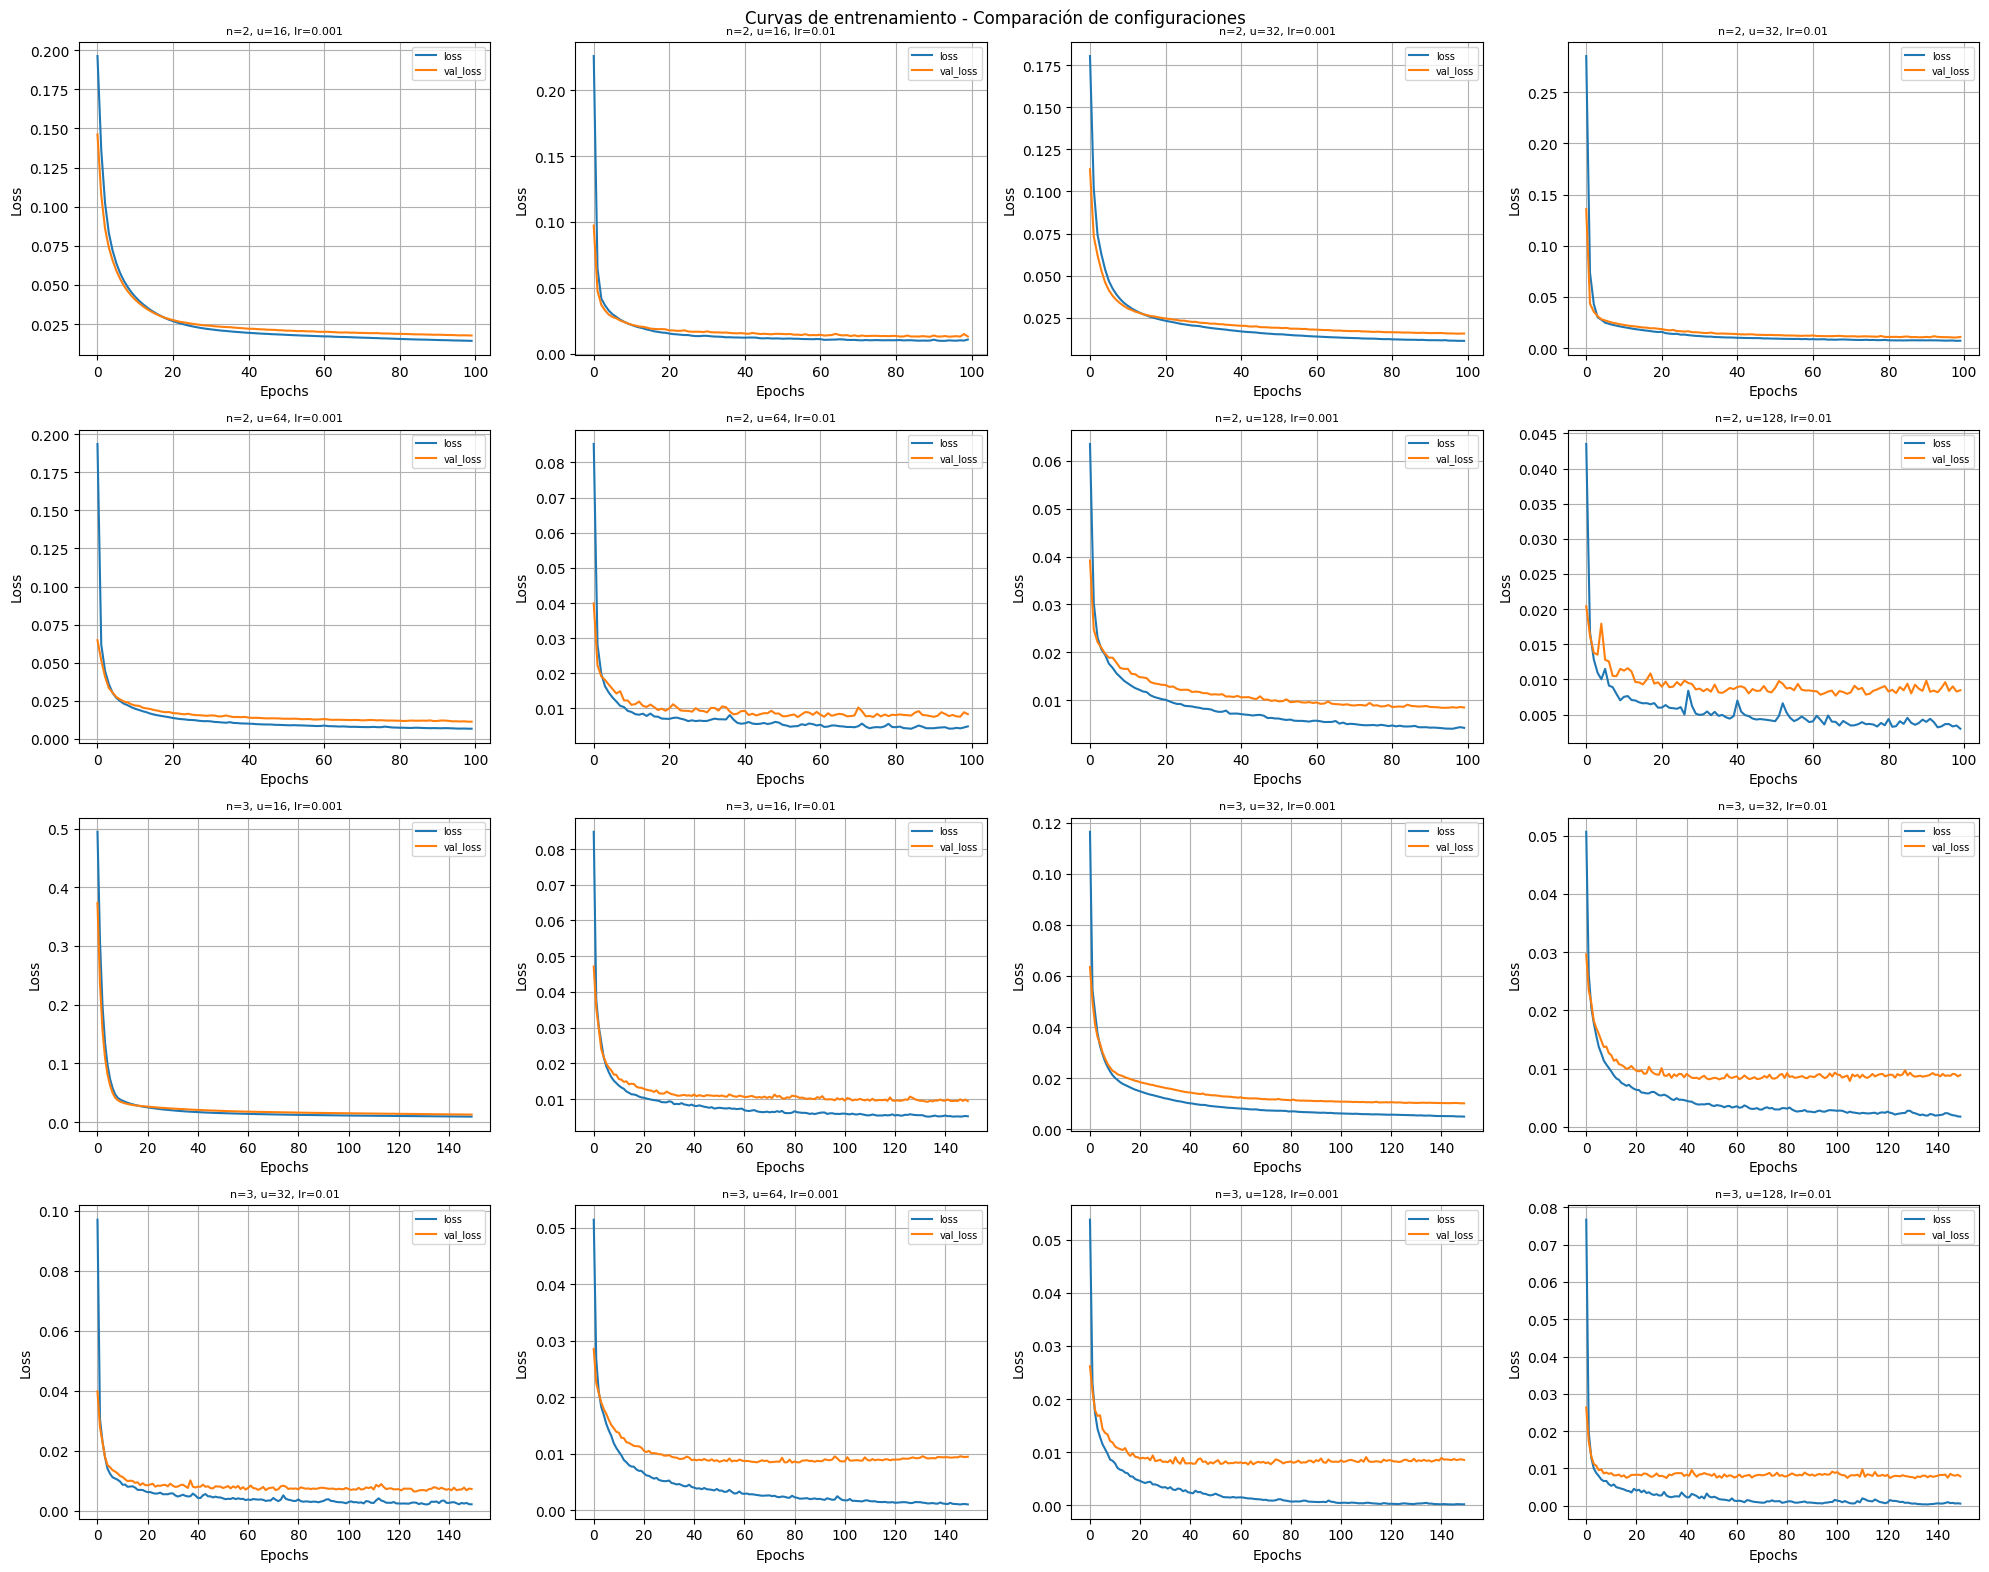

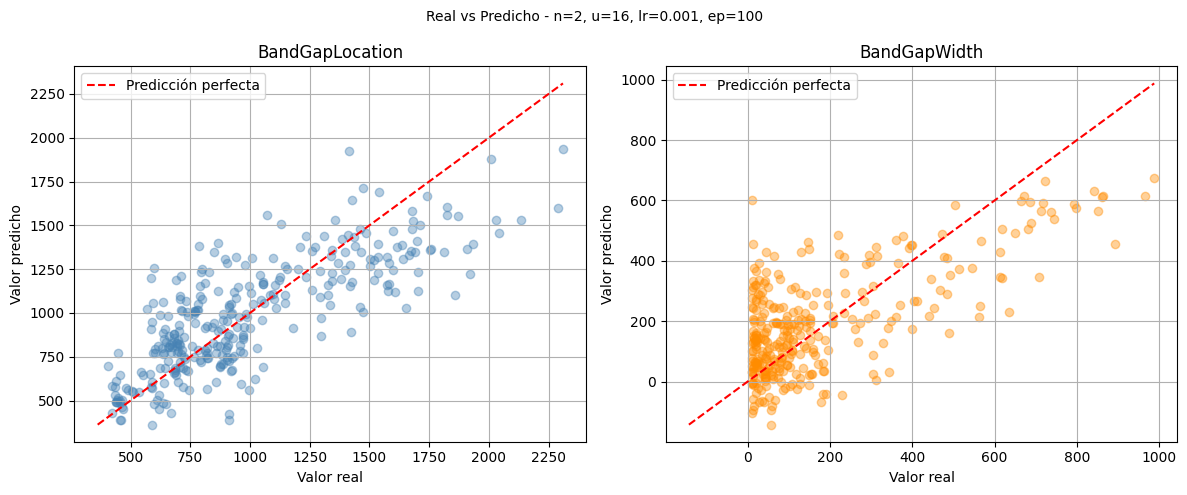


=== n=2, u=16, lr=0.001, ep=100 ===
  BandGapLocation - R²: 0.6175 | MAE: 193.19 | Error promedio: 20.6%
    Dentro del 5%: 15.7%
    Dentro del 10%: 30.5%
    Dentro del 20%: 58.5%
  BandGapWidth - R²: 0.4467 | MAE: 123.56 | Error promedio: 284.4%
    Dentro del 5%: 2.2%
    Dentro del 10%: 6.6%
    Dentro del 20%: 12.9%


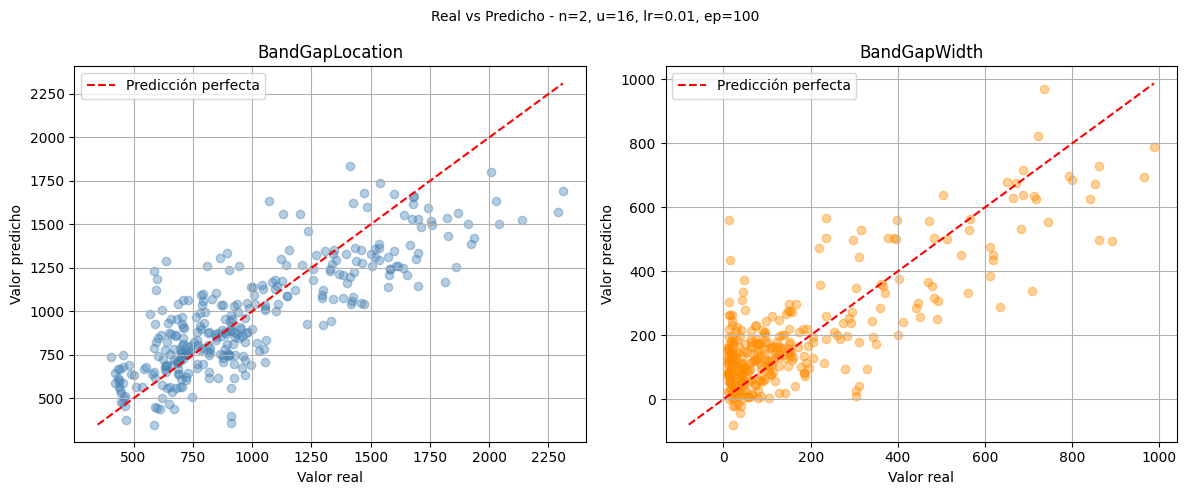


=== n=2, u=16, lr=0.01, ep=100 ===
  BandGapLocation - R²: 0.6719 | MAE: 177.86 | Error promedio: 19.3%
    Dentro del 5%: 18.2%
    Dentro del 10%: 34.9%
    Dentro del 20%: 62.6%
  BandGapWidth - R²: 0.6533 | MAE: 94.24 | Error promedio: 224.3%
    Dentro del 5%: 5.3%
    Dentro del 10%: 10.1%
    Dentro del 20%: 20.8%


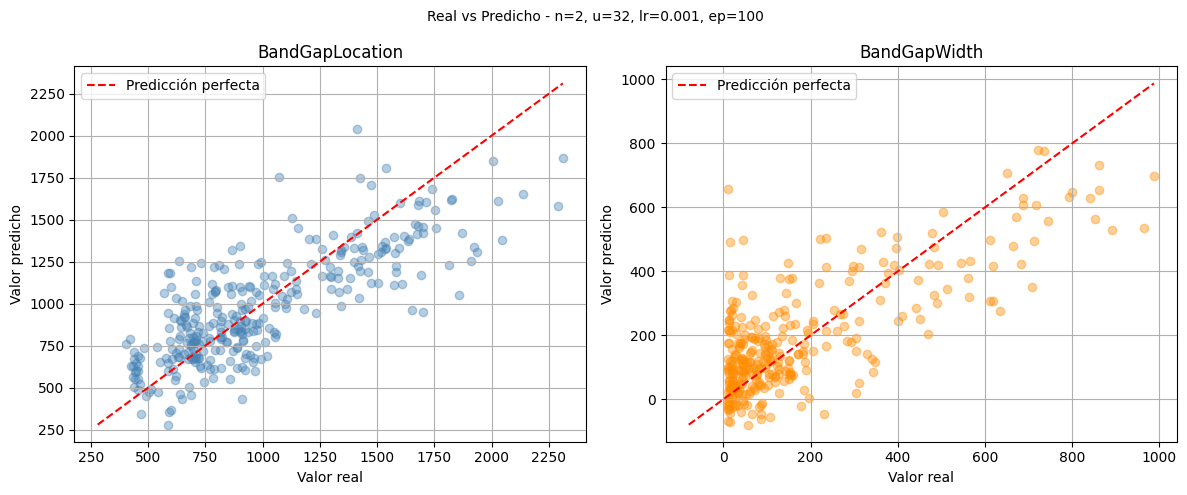


=== n=2, u=32, lr=0.001, ep=100 ===
  BandGapLocation - R²: 0.6226 | MAE: 191.60 | Error promedio: 21.2%
    Dentro del 5%: 15.1%
    Dentro del 10%: 32.1%
    Dentro del 20%: 58.8%
  BandGapWidth - R²: 0.5671 | MAE: 103.75 | Error promedio: 228.1%
    Dentro del 5%: 3.1%
    Dentro del 10%: 7.2%
    Dentro del 20%: 17.6%


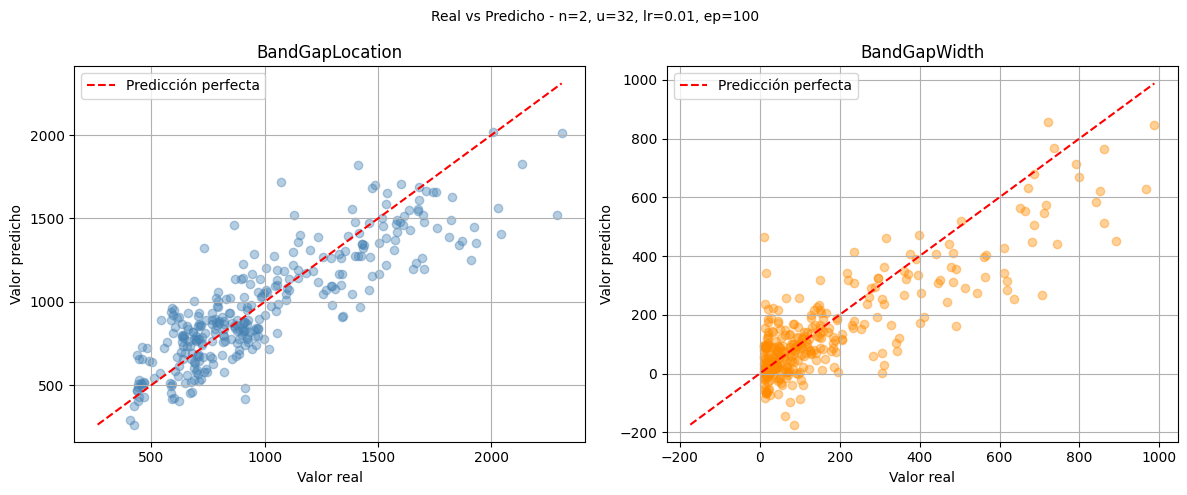


=== n=2, u=32, lr=0.01, ep=100 ===
  BandGapLocation - R²: 0.7425 | MAE: 155.86 | Error promedio: 16.8%
    Dentro del 5%: 17.3%
    Dentro del 10%: 39.0%
    Dentro del 20%: 66.7%
  BandGapWidth - R²: 0.6946 | MAE: 83.10 | Error promedio: 148.6%
    Dentro del 5%: 5.7%
    Dentro del 10%: 11.9%
    Dentro del 20%: 23.6%


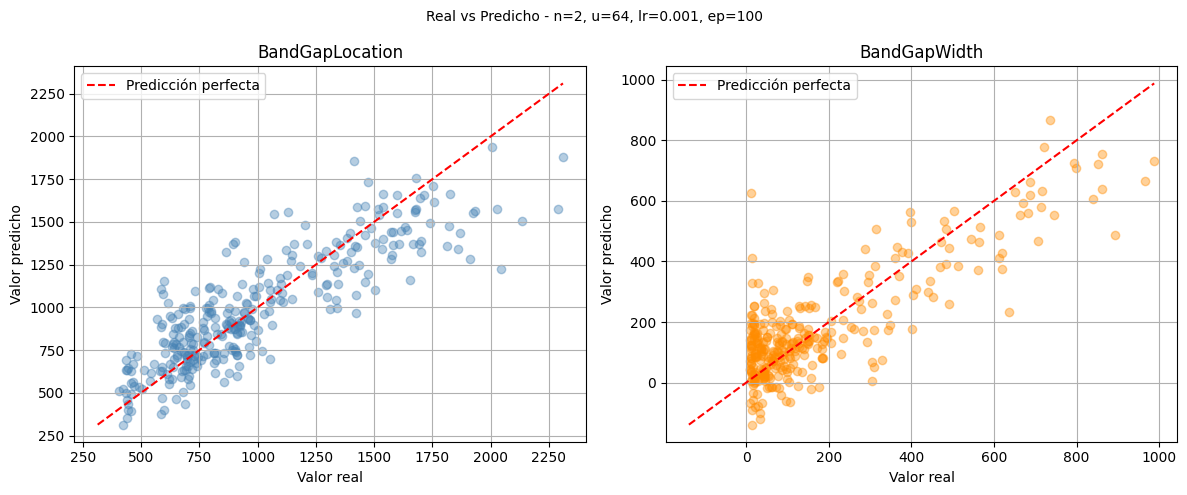


=== n=2, u=64, lr=0.001, ep=100 ===
  BandGapLocation - R²: 0.7390 | MAE: 154.48 | Error promedio: 16.9%
    Dentro del 5%: 23.3%
    Dentro del 10%: 43.1%
    Dentro del 20%: 67.9%
  BandGapWidth - R²: 0.6825 | MAE: 90.25 | Error promedio: 216.6%
    Dentro del 5%: 4.4%
    Dentro del 10%: 10.4%
    Dentro del 20%: 24.8%


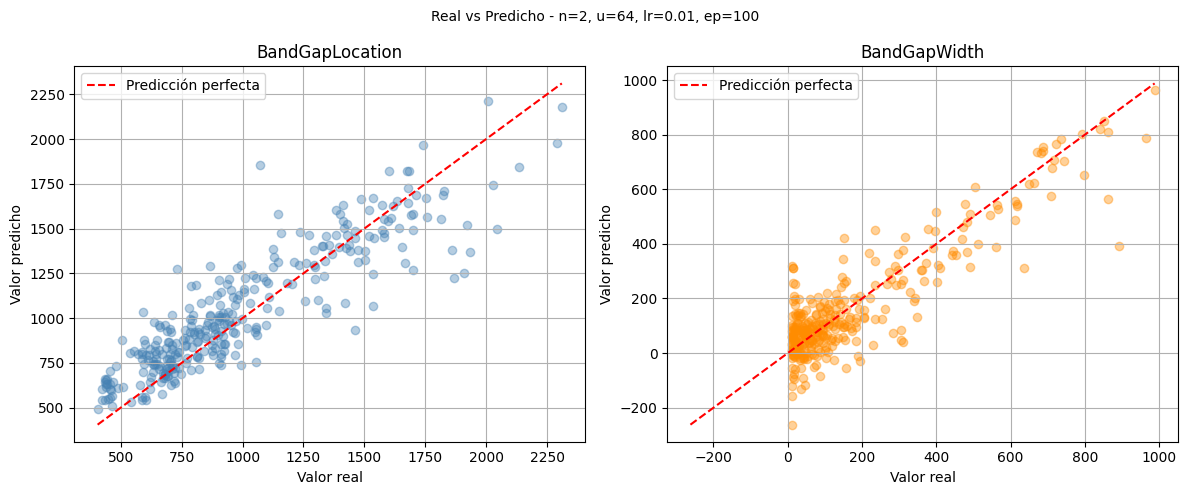


=== n=2, u=64, lr=0.01, ep=100 ===
  BandGapLocation - R²: 0.7863 | MAE: 141.97 | Error promedio: 16.2%
    Dentro del 5%: 20.8%
    Dentro del 10%: 42.1%
    Dentro del 20%: 70.1%
  BandGapWidth - R²: 0.7850 | MAE: 72.13 | Error promedio: 163.0%
    Dentro del 5%: 7.5%
    Dentro del 10%: 15.1%
    Dentro del 20%: 24.2%


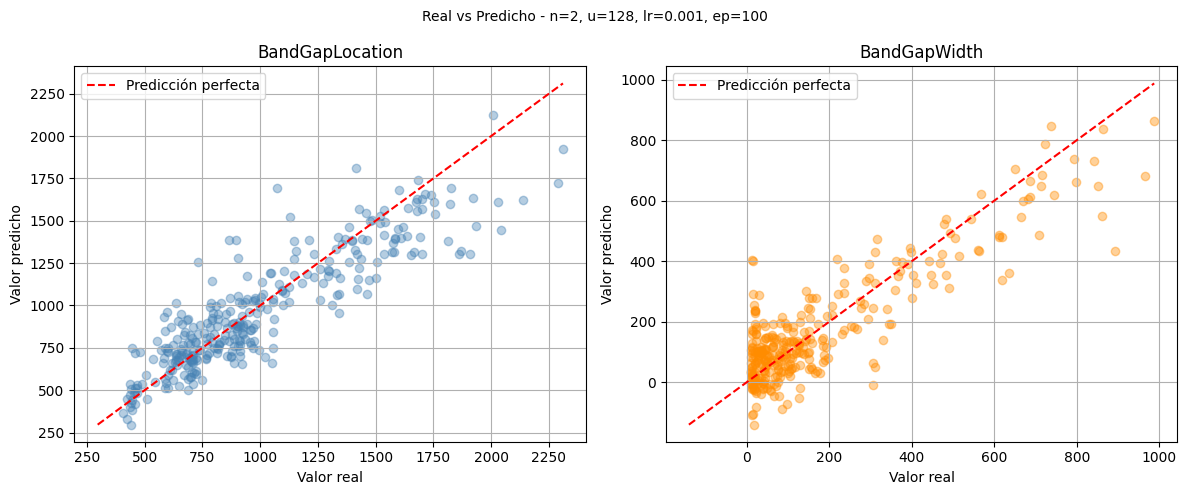


=== n=2, u=128, lr=0.001, ep=100 ===
  BandGapLocation - R²: 0.7930 | MAE: 133.94 | Error promedio: 14.0%
    Dentro del 5%: 23.6%
    Dentro del 10%: 46.9%
    Dentro del 20%: 75.5%
  BandGapWidth - R²: 0.7669 | MAE: 76.66 | Error promedio: 170.0%
    Dentro del 5%: 5.7%
    Dentro del 10%: 10.7%
    Dentro del 20%: 24.2%


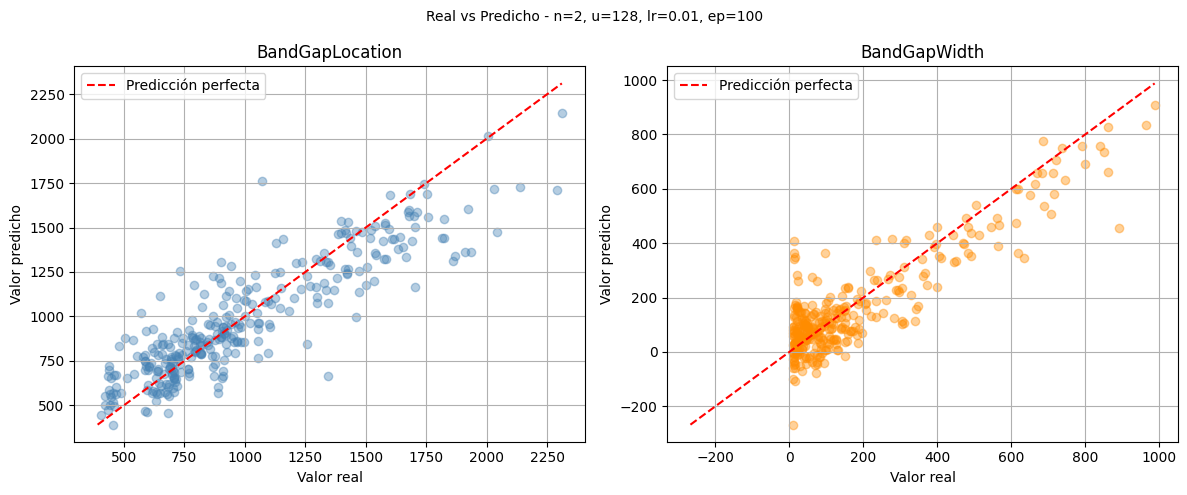


=== n=2, u=128, lr=0.01, ep=100 ===
  BandGapLocation - R²: 0.7824 | MAE: 138.29 | Error promedio: 15.2%
    Dentro del 5%: 24.5%
    Dentro del 10%: 46.2%
    Dentro del 20%: 73.6%
  BandGapWidth - R²: 0.7842 | MAE: 72.88 | Error promedio: 170.9%
    Dentro del 5%: 9.4%
    Dentro del 10%: 14.2%
    Dentro del 20%: 26.1%


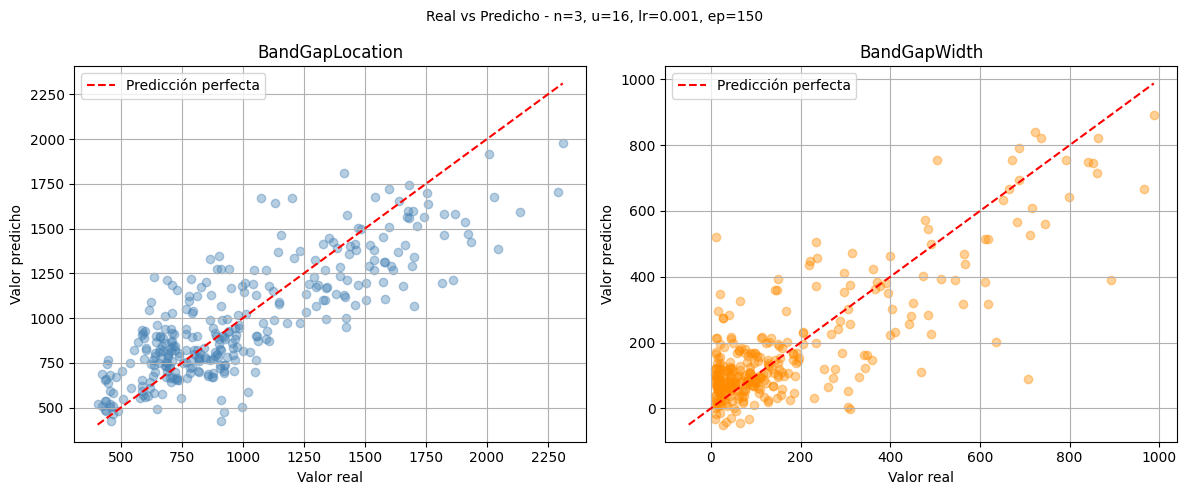


=== n=3, u=16, lr=0.001, ep=150 ===
  BandGapLocation - R²: 0.6729 | MAE: 180.64 | Error promedio: 19.6%
    Dentro del 5%: 16.4%
    Dentro del 10%: 34.3%
    Dentro del 20%: 61.6%
  BandGapWidth - R²: 0.6751 | MAE: 84.63 | Error promedio: 170.0%
    Dentro del 5%: 6.6%
    Dentro del 10%: 10.4%
    Dentro del 20%: 25.2%


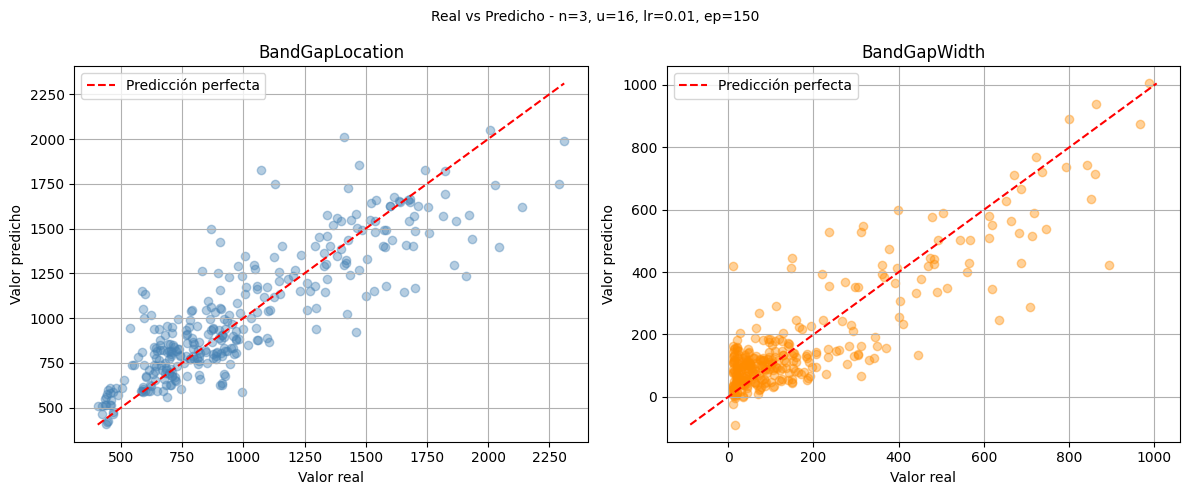


=== n=3, u=16, lr=0.01, ep=150 ===
  BandGapLocation - R²: 0.7517 | MAE: 144.51 | Error promedio: 15.5%
    Dentro del 5%: 24.8%
    Dentro del 10%: 44.7%
    Dentro del 20%: 72.3%
  BandGapWidth - R²: 0.7671 | MAE: 74.10 | Error promedio: 140.8%
    Dentro del 5%: 5.0%
    Dentro del 10%: 11.3%
    Dentro del 20%: 23.3%


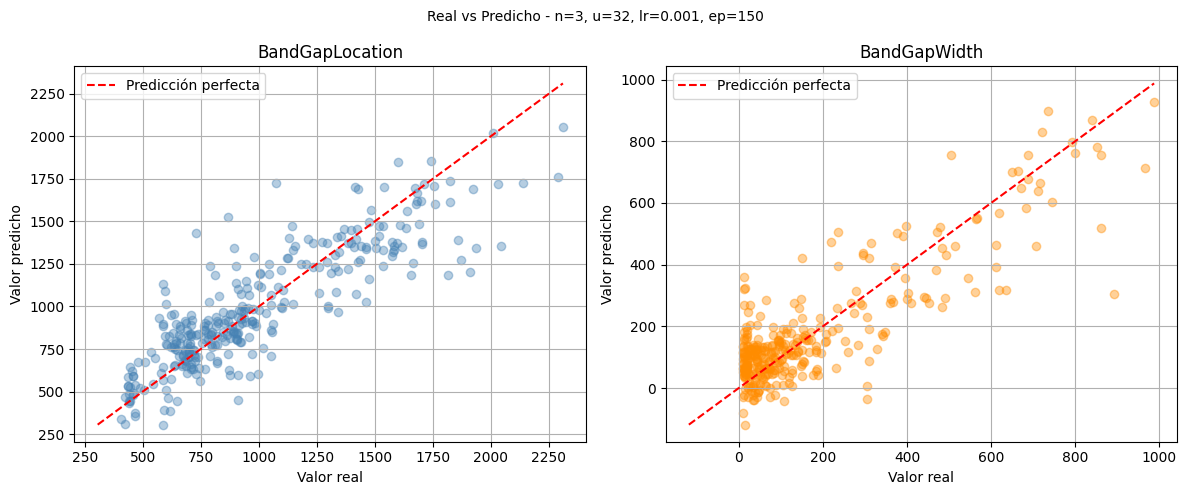


=== n=3, u=32, lr=0.001, ep=150 ===
  BandGapLocation - R²: 0.7485 | MAE: 147.74 | Error promedio: 16.0%
    Dentro del 5%: 23.9%
    Dentro del 10%: 43.7%
    Dentro del 20%: 72.0%
  BandGapWidth - R²: 0.7299 | MAE: 81.26 | Error promedio: 182.6%
    Dentro del 5%: 6.3%
    Dentro del 10%: 12.9%
    Dentro del 20%: 24.2%


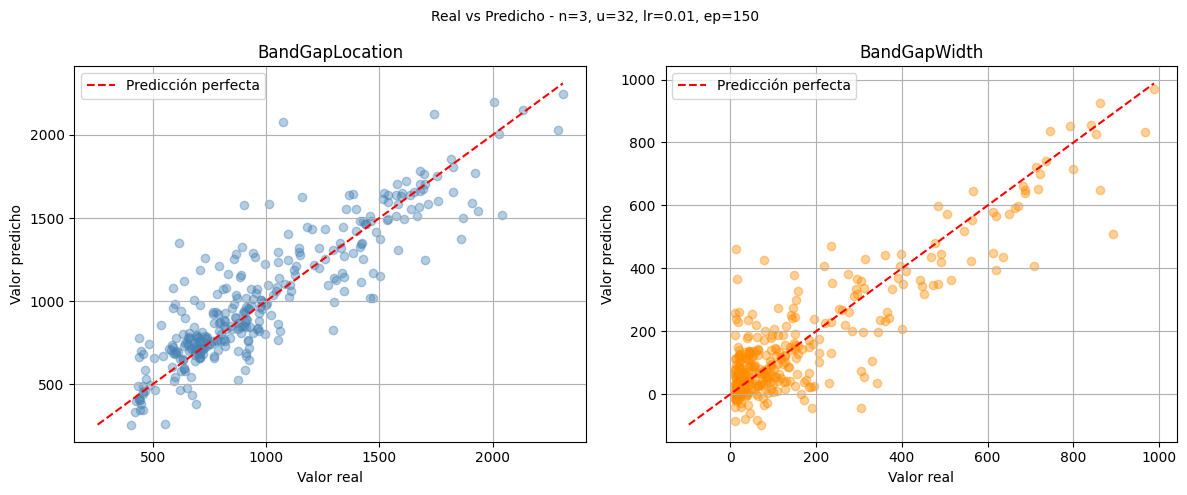


=== n=3, u=32, lr=0.01, ep=150 ===
  BandGapLocation - R²: 0.7713 | MAE: 133.01 | Error promedio: 15.2%
    Dentro del 5%: 31.1%
    Dentro del 10%: 52.8%
    Dentro del 20%: 74.5%
  BandGapWidth - R²: 0.7715 | MAE: 73.16 | Error promedio: 146.5%
    Dentro del 5%: 8.8%
    Dentro del 10%: 16.7%
    Dentro del 20%: 27.7%


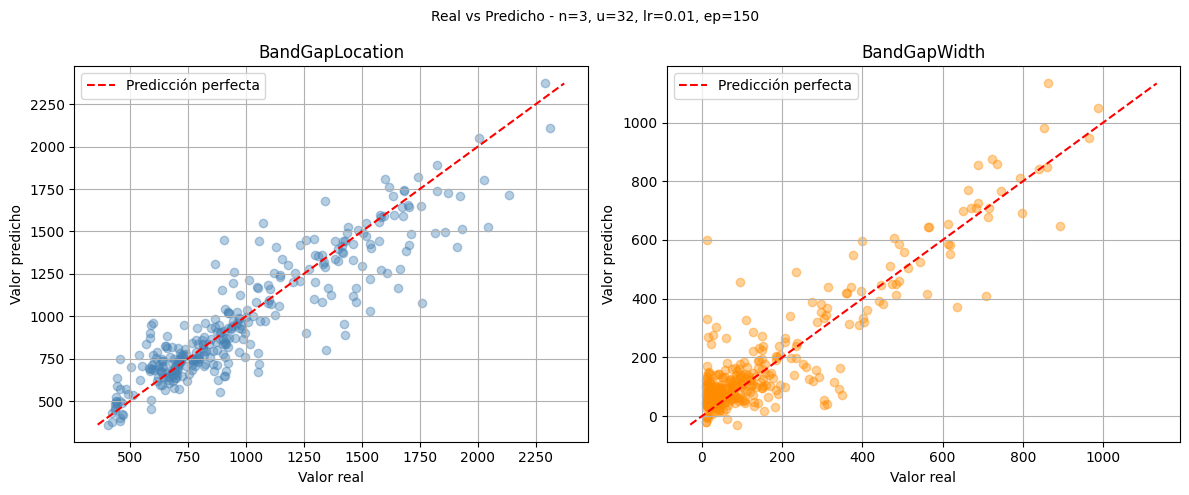


=== n=3, u=32, lr=0.01, ep=150 ===
  BandGapLocation - R²: 0.8256 | MAE: 115.20 | Error promedio: 12.1%
    Dentro del 5%: 35.5%
    Dentro del 10%: 56.9%
    Dentro del 20%: 81.4%
  BandGapWidth - R²: 0.7977 | MAE: 65.82 | Error promedio: 149.2%
    Dentro del 5%: 7.5%
    Dentro del 10%: 14.5%
    Dentro del 20%: 27.7%


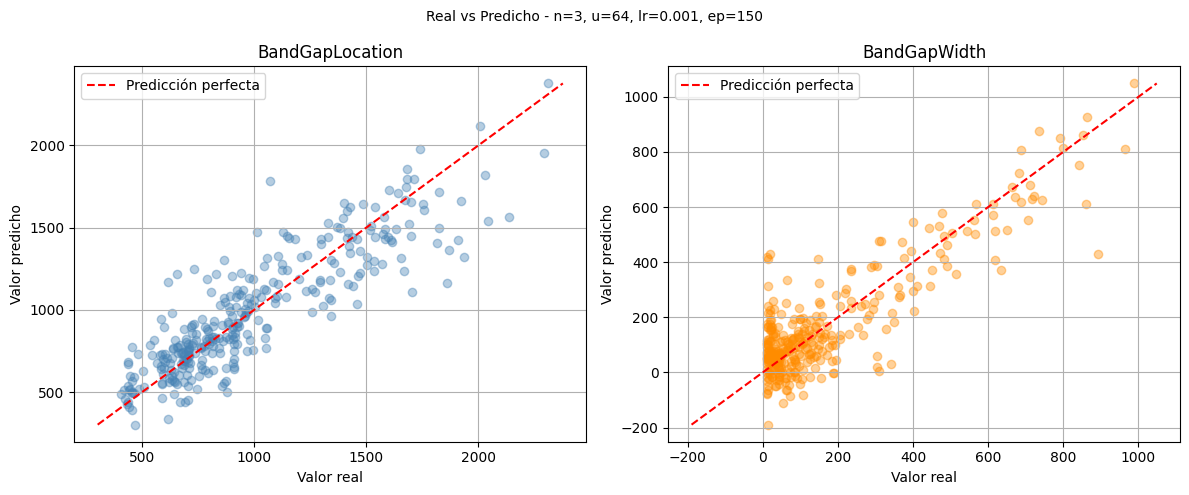


=== n=3, u=64, lr=0.001, ep=150 ===
  BandGapLocation - R²: 0.7691 | MAE: 144.84 | Error promedio: 15.6%
    Dentro del 5%: 20.4%
    Dentro del 10%: 45.0%
    Dentro del 20%: 71.1%
  BandGapWidth - R²: 0.7411 | MAE: 80.76 | Error promedio: 191.1%
    Dentro del 5%: 5.7%
    Dentro del 10%: 12.3%
    Dentro del 20%: 22.0%


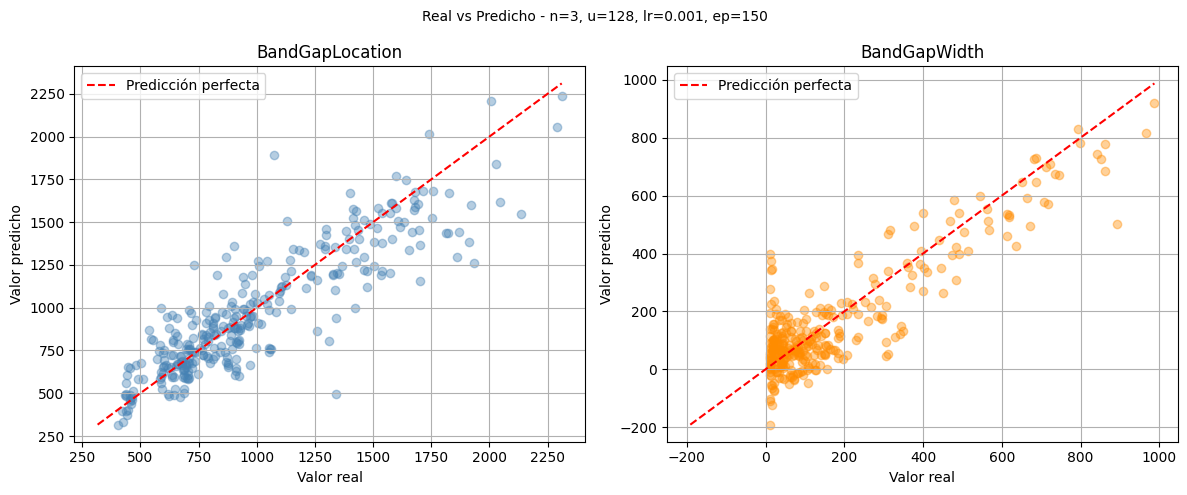


=== n=3, u=128, lr=0.001, ep=150 ===
  BandGapLocation - R²: 0.7784 | MAE: 134.97 | Error promedio: 14.2%
    Dentro del 5%: 25.8%
    Dentro del 10%: 48.7%
    Dentro del 20%: 74.2%
  BandGapWidth - R²: 0.7857 | MAE: 74.25 | Error promedio: 175.7%
    Dentro del 5%: 5.7%
    Dentro del 10%: 14.5%
    Dentro del 20%: 26.7%


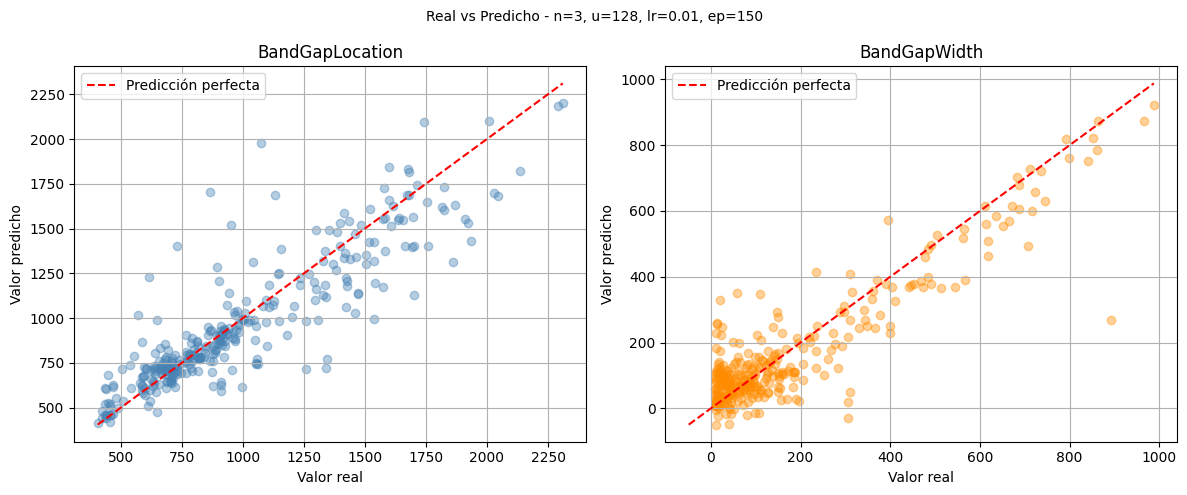


=== n=3, u=128, lr=0.01, ep=150 ===
  BandGapLocation - R²: 0.7796 | MAE: 122.82 | Error promedio: 12.5%
    Dentro del 5%: 34.3%
    Dentro del 10%: 59.7%
    Dentro del 20%: 82.4%
  BandGapWidth - R²: 0.8226 | MAE: 60.83 | Error promedio: 124.6%
    Dentro del 5%: 10.4%
    Dentro del 10%: 20.1%
    Dentro del 20%: 31.1%


In [ ]:

# Comparación de hiperparámetros


configuraciones = [
    {'n': 2, 'units': 16,  'learning_rate': 0.001, 'epochs': 100, 'batch_size': 100},
    {'n': 2, 'units': 16,  'learning_rate': 0.01,  'epochs': 100, 'batch_size': 100},
    {'n': 2, 'units': 32,  'learning_rate': 0.001, 'epochs': 100, 'batch_size': 100},
    {'n': 2, 'units': 32,  'learning_rate': 0.01,  'epochs': 100, 'batch_size': 100},
    {'n': 2, 'units': 64,  'learning_rate': 0.001, 'epochs': 100, 'batch_size': 50},
    {'n': 2, 'units': 64,  'learning_rate': 0.01,  'epochs': 100, 'batch_size': 50},
    {'n': 2, 'units': 128, 'learning_rate': 0.001, 'epochs': 100, 'batch_size': 50},
    {'n': 2, 'units': 128, 'learning_rate': 0.01,  'epochs': 100, 'batch_size': 50},
    {'n': 3, 'units': 16,  'learning_rate': 0.001, 'epochs': 150, 'batch_size': 100},
    {'n': 3, 'units': 16,  'learning_rate': 0.01,  'epochs': 150, 'batch_size': 100},
    {'n': 3, 'units': 32,  'learning_rate': 0.001, 'epochs': 150, 'batch_size': 100},
    {'n': 3, 'units': 32,  'learning_rate': 0.01,  'epochs': 150, 'batch_size': 100},
    {'n': 3, 'units': 32,  'learning_rate': 0.01,  'epochs': 150, 'batch_size': 50},
    {'n': 3, 'units': 64,  'learning_rate': 0.001, 'epochs': 150, 'batch_size': 50},
    {'n': 3, 'units': 128, 'learning_rate': 0.001, 'epochs': 150, 'batch_size': 50},
    {'n': 3, 'units': 128, 'learning_rate': 0.01,  'epochs': 150, 'batch_size': 50},
]

modelos_comparacion = []

for config in configuraciones:
    history, modelo = entrenar_modelo(
        n=config['n'],
        units=config['units'],
        learning_rate=config['learning_rate'],
        train_set=new_trainset[['BandGapLocation', 'BandGapWidth']],
        test_set=new_testset[['BandGapLocation', 'BandGapWidth']],
        n_output=2,
        epochs=config['epochs'],
        batch_size=config['batch_size']
    )
    modelos_comparacion.append({'config': config, 'history': history, 'modelo': modelo})

# ============================================================
# CURVAS DE ENTRENAMIENTO
# ============================================================

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for idx, entry in enumerate(modelos_comparacion):
    config = entry['config']
    hist = entry['history'].history
    label = f"n={config['n']}, u={config['units']}, lr={config['learning_rate']}"
    axes[idx].plot(hist['loss'], label='loss')
    axes[idx].plot(hist['val_loss'], label='val_loss')
    axes[idx].set_title(label, fontsize=8)
    axes[idx].set_xlabel("Epochs")
    axes[idx].set_ylabel("Loss")
    axes[idx].legend(fontsize=7)
    axes[idx].grid()

plt.suptitle("Curvas de entrenamiento - Comparación de configuraciones")
plt.tight_layout()
plt.show()
# ============================================================
# GRÁFICOS DE DISPERSIÓN Y PORCENTAJE DE ERROR
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for entry in modelos_comparacion:
    config = entry['config']
    modelo = entry['modelo']
    label = f"n={config['n']}, u={config['units']}, lr={config['learning_rate']}, ep={config['epochs']}"

    predicciones = modelo.predict(x_test, verbose=0)
    pred_desnorm = predicciones * difference[['BandGapLocation', 'BandGapWidth']].values + min_val_train[['BandGapLocation', 'BandGapWidth']].values
    real_desnorm = new_testset[['BandGapLocation', 'BandGapWidth']].values * difference[['BandGapLocation', 'BandGapWidth']].values + min_val_train[['BandGapLocation', 'BandGapWidth']].values

    # Gráfico de dispersión
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Real vs Predicho - {label}", fontsize=10)

    for i, col in enumerate(['BandGapLocation', 'BandGapWidth']):
        axes[i].scatter(real_desnorm[:, i], pred_desnorm[:, i], alpha=0.4, color='steelblue' if i == 0 else 'darkorange')
        min_v = min(real_desnorm[:, i].min(), pred_desnorm[:, i].min())
        max_v = max(real_desnorm[:, i].max(), pred_desnorm[:, i].max())
        axes[i].plot([min_v, max_v], [min_v, max_v], 'r--', label='Predicción perfecta')
        axes[i].set_xlabel("Valor real")
        axes[i].set_ylabel("Valor predicho")
        axes[i].set_title(col)
        axes[i].legend()
        axes[i].grid()

    plt.tight_layout()
    plt.show()

    # Métricas y porcentaje de error
    print(f"\n=== {label} ===")
    for i, col in enumerate(['BandGapLocation', 'BandGapWidth']):
        r2  = r2_score(real_desnorm[:, i], pred_desnorm[:, i])
        mae = mean_absolute_error(real_desnorm[:, i], pred_desnorm[:, i])
        error_porcentual = np.abs((real_desnorm[:, i] - pred_desnorm[:, i]) / real_desnorm[:, i]) * 100
        print(f"  {col} - R²: {r2:.4f} | MAE: {mae:.2f} | Error promedio: {np.mean(error_porcentual):.1f}%")
        for margen in [5, 10, 20]:
            aciertos = np.mean(error_porcentual <= margen) * 100
            print(f"    Dentro del {margen}%: {aciertos:.1f}%")

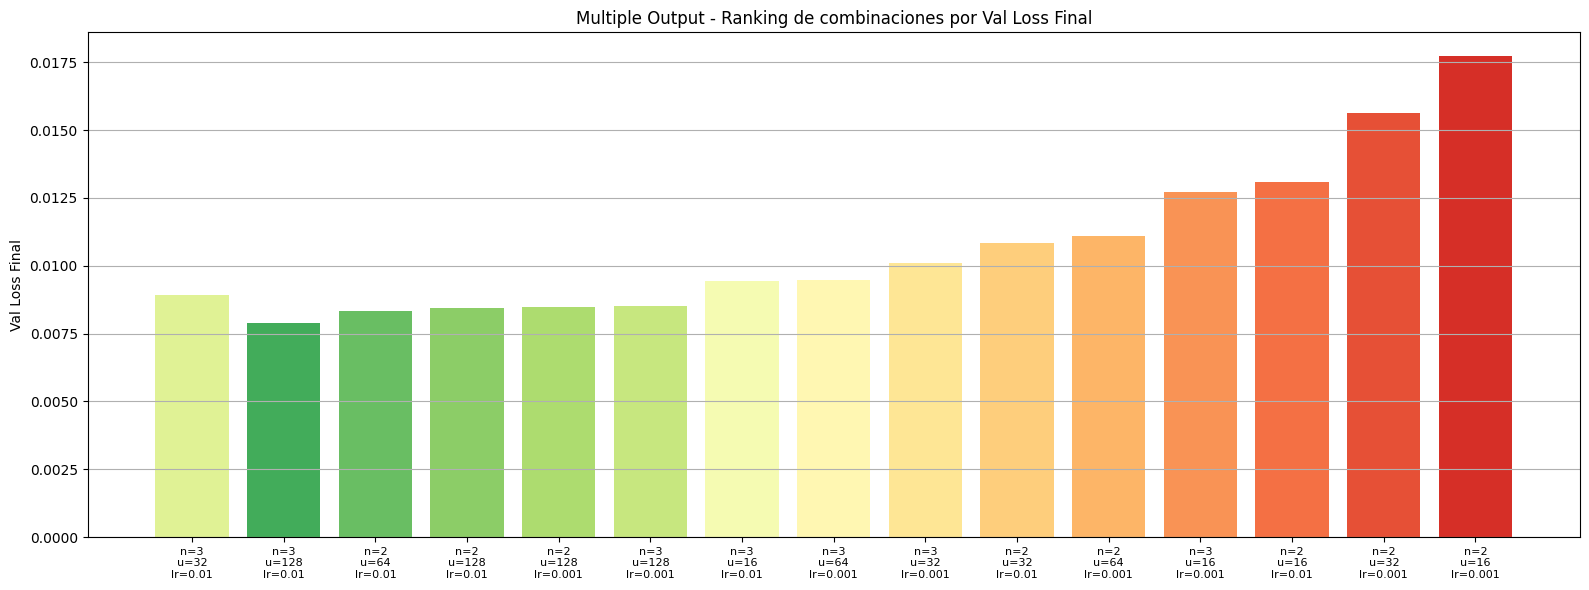


=== RANKING ===
1. n=3, u=32, lr=0.01 → val_loss = 0.0073
2. n=3, u=128, lr=0.01 → val_loss = 0.0079
3. n=2, u=64, lr=0.01 → val_loss = 0.0084
4. n=2, u=128, lr=0.01 → val_loss = 0.0084
5. n=2, u=128, lr=0.001 → val_loss = 0.0085
6. n=3, u=128, lr=0.001 → val_loss = 0.0085
7. n=3, u=32, lr=0.01 → val_loss = 0.0089
8. n=3, u=16, lr=0.01 → val_loss = 0.0094
9. n=3, u=64, lr=0.001 → val_loss = 0.0095
10. n=3, u=32, lr=0.001 → val_loss = 0.0101
11. n=2, u=32, lr=0.01 → val_loss = 0.0108
12. n=2, u=64, lr=0.001 → val_loss = 0.0111
13. n=3, u=16, lr=0.001 → val_loss = 0.0127
14. n=2, u=16, lr=0.01 → val_loss = 0.0131
15. n=2, u=32, lr=0.001 → val_loss = 0.0156
16. n=2, u=16, lr=0.001 → val_loss = 0.0177


In [ ]:
# ============================================================
# RANKING DE CONFIGURACIONES POR VAL_LOSS FINAL
# ============================================================

# Se extrae el val_loss final de cada configuración
ranking = []
for entry in modelos_comparacion:
    config = entry['config']
    val_loss_final = entry['history'].history['val_loss'][-1]
    label = f"n={config['n']}\nu={config['units']}\nlr={config['learning_rate']}"
    ranking.append({'label': label, 'val_loss': val_loss_final})

# Se ordena de menor a mayor
ranking = sorted(ranking, key=lambda x: x['val_loss'])

labels = [r['label'] for r in ranking]
val_losses = [r['val_loss'] for r in ranking]

# Colores en gradiente verde -> rojo
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(ranking)))

plt.figure(figsize=(16, 6))
plt.bar(labels, val_losses, color=colors)
plt.title("Multiple Output - Ranking de combinaciones por Val Loss Final")
plt.ylabel("Val Loss Final")
plt.xticks(rotation=0, fontsize=8)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Se imprime también en texto
print("\n=== RANKING ===")
for i, r in enumerate(ranking, 1):
    print(f"{i}. {r['label'].replace(chr(10), ', ')} → val_loss = {r['val_loss']:.4f}")

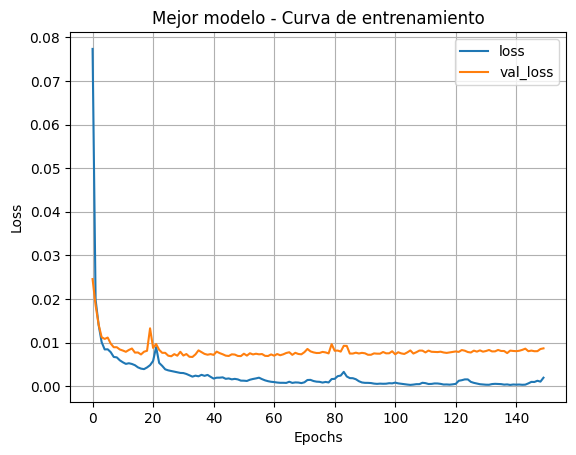

In [ ]:
history_mejor, mejor_modelo = entrenar_modelo(
    n=3,
    units=128,
    learning_rate=0.01,
    train_set=new_trainset[['BandGapLocation','BandGapWidth']],
    test_set=new_testset[['BandGapLocation','BandGapWidth']],
    n_output=2,
    epochs=150,
    batch_size=50

)

# Ver la curva de entrenamiento
plt.figure()
plt.plot(history_mejor.history['loss'], label='loss')
plt.plot(history_mejor.history['val_loss'], label='val_loss')
plt.title("Mejor modelo - Curva de entrenamiento")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ============================================================
# VALIDACIÓN: comparación de valores reales vs predichos
# ============================================================

# Se eligen 10 datos al azar del test set
np.random.seed(42)
indices_val = np.random.choice(len(x_test), size=10, replace=False)

for idx in indices_val:
    dato = x_test[idx]
    real_norm = new_testset[['BandGapLocation', 'BandGapWidth']].iloc[idx]

    # Se predice
    pred_norm = mejor_modelo.predict(dato.reshape(1, -1), verbose=0)[0]

    # Se desnormaliza
    loc_real = real_norm['BandGapLocation'] * difference['BandGapLocation'] + min_val_train['BandGapLocation']
    width_real = real_norm['BandGapWidth'] * difference['BandGapWidth'] + min_val_train['BandGapWidth']

    loc_pred = pred_norm[0] * difference['BandGapLocation'] + min_val_train['BandGapLocation']
    width_pred = pred_norm[1] * difference['BandGapWidth'] + min_val_train['BandGapWidth']

    print(f"\nDato ingresado: {dato}")
    print(f"  BandGapLocation  - Real: {loc_real:.2f}  |  Estimado: {loc_pred:.2f}")
    print(f"  BandGapWidth     - Real: {width_real:.2f}  |  Estimado: {width_pred:.2f}")


Dato ingresado: [0 0 0 0 1 1 0 0 0 1 1 0 0 1 0]
  BandGapLocation  - Real: 699.93  |  Estimado: 696.81
  BandGapWidth     - Real: 119.00  |  Estimado: 54.68

Dato ingresado: [0 0 0 0 1 0 0 1 1 0 0 1 0 1 0]
  BandGapLocation  - Real: 819.26  |  Estimado: 706.23
  BandGapWidth     - Real: 472.55  |  Estimado: 338.81

Dato ingresado: [0 0 0 0 0 0 0 0 1 1 1 0 0 1 1]
  BandGapLocation  - Real: 1050.69  |  Estimado: 758.52
  BandGapWidth     - Real: 158.92  |  Estimado: 87.91

Dato ingresado: [0 0 0 0 0 1 0 1 0 1 0 1 0 1 0]
  BandGapLocation  - Real: 820.08  |  Estimado: 691.83
  BandGapWidth     - Real: 446.09  |  Estimado: 307.94

Dato ingresado: [0 0 0 0 1 1 0 0 1 0 0 0 1 1 1]
  BandGapLocation  - Real: 994.82  |  Estimado: 730.02
  BandGapWidth     - Real: 892.43  |  Estimado: 497.27

Dato ingresado: [0 0 0 0 0 0 0 1 0 0 0 1 1 1 0]
  BandGapLocation  - Real: 812.64  |  Estimado: 820.42
  BandGapWidth     - Real: 396.05  |  Estimado: 508.22

Dato ingresado: [0 0 0 0 1 1 0 0 1 0 0 1 0 0 0

# Punto 3

Escogemos como modelo el de multiple output ya que es mas sencillo de analizar y da resultados similares a los obtenidos con single output.


--- BandGapLocation ---
  MSE  : 41367.8153
  RMSE : 203.3908
  MAE  : 135.6175
  R²   : 0.7459

--- BandGapWidth ---
  MSE  : 8203.9016
  RMSE : 90.5754
  MAE  : 60.8780
  R²   : 0.8200


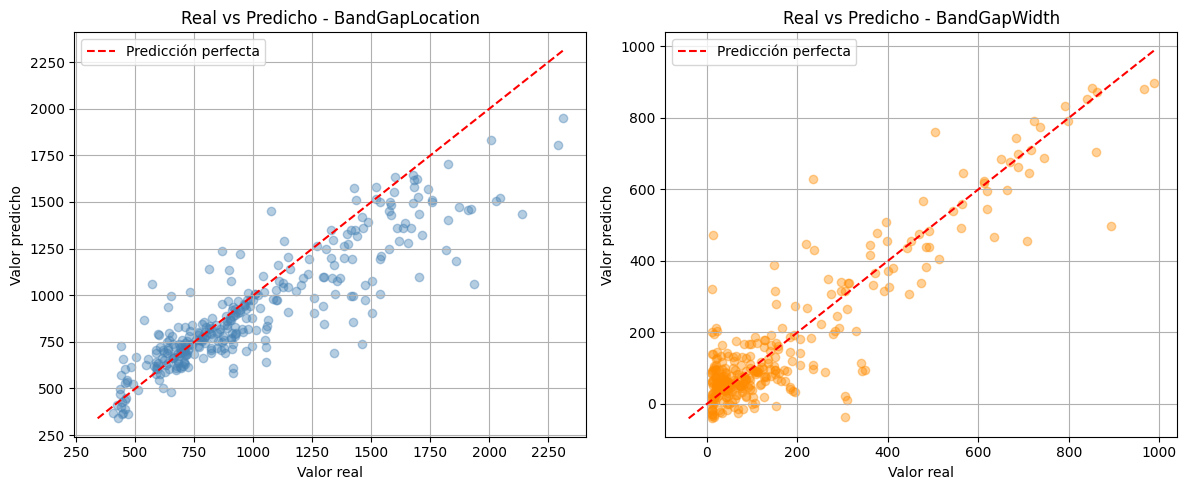

In [ ]:
# ============================================================
# VALIDACIÓN DEL MODELO CON EL TEST SET
# ============================================================

# Predicciones sobre el test set
predicciones = mejor_modelo.predict(x_test, verbose=0)

# Desnormalización de las predicciones y valores reales
# (para interpretar los resultados en la escala original)
pred_desnorm = predicciones * difference[['BandGapLocation', 'BandGapWidth']].values + min_val_train[['BandGapLocation', 'BandGapWidth']].values
real_desnorm = new_testset[['BandGapLocation', 'BandGapWidth']].values * difference[['BandGapLocation', 'BandGapWidth']].values + min_val_train[['BandGapLocation', 'BandGapWidth']].values

# Métricas por salida
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for i, col in enumerate(['BandGapLocation', 'BandGapWidth']):
    mse  = mean_squared_error(real_desnorm[:, i], pred_desnorm[:, i])
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(real_desnorm[:, i], pred_desnorm[:, i])
    r2   = r2_score(real_desnorm[:, i], pred_desnorm[:, i])

    print(f"\n--- {col} ---")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

# Gráfico de predicho vs real
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(['BandGapLocation', 'BandGapWidth']):
    axes[i].scatter(real_desnorm[:, i], pred_desnorm[:, i], alpha=0.4, color='steelblue' if i==0 else 'darkorange')
    min_val = min(real_desnorm[:, i].min(), pred_desnorm[:, i].min())
    max_val = max(real_desnorm[:, i].max(), pred_desnorm[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')
    axes[i].set_xlabel("Valor real")
    axes[i].set_ylabel("Valor predicho")
    axes[i].set_title(f"Real vs Predicho - {col}")
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

In [ ]:
# Porcentaje de aciertos dentro de un margen de error
for i, col in enumerate(['BandGapLocation', 'BandGapWidth']):
    error_porcentual = np.abs((real_desnorm[:, i] - pred_desnorm[:, i]) / real_desnorm[:, i]) * 100

    for margen in [5, 10, 20]:
        aciertos = np.mean(error_porcentual <= margen) * 100
        print(f"{col} - Predicciones dentro del {margen}% de error: {aciertos:.1f}%")

    print(f"{col} - Error porcentual promedio: {np.mean(error_porcentual):.1f}%\n")

BandGapLocation - Predicciones dentro del 5% de error: 33.0%
BandGapLocation - Predicciones dentro del 10% de error: 53.8%
BandGapLocation - Predicciones dentro del 20% de error: 78.0%
BandGapLocation - Error porcentual promedio: 13.0%

BandGapWidth - Predicciones dentro del 5% de error: 9.7%
BandGapWidth - Predicciones dentro del 10% de error: 17.6%
BandGapWidth - Predicciones dentro del 20% de error: 30.2%
BandGapWidth - Error porcentual promedio: 127.4%



4 diseños elegidos al azar:
  Diseño 1: [0 0 0 0 1 1 0 0 0 1 1 0 0 1 0]
  Diseño 2: [0 0 0 0 1 0 0 1 1 0 0 1 0 1 0]
  Diseño 3: [0 0 0 0 0 0 0 0 1 1 1 0 0 1 1]
  Diseño 4: [0 0 0 0 0 1 0 1 0 1 0 1 0 1 0]

Diseño 1:
  Píxel con mayor variación en BandGapLocation : Píxel 8 (variación=0.3817)
  Píxel con mayor variación en BandGapWidth    : Píxel 11 (variación=0.1563)

Diseño 2:
  Píxel con mayor variación en BandGapLocation : Píxel 11 (variación=0.4416)
  Píxel con mayor variación en BandGapWidth    : Píxel 13 (variación=0.4716)

Diseño 3:
  Píxel con mayor variación en BandGapLocation : Píxel 8 (variación=0.2368)
  Píxel con mayor variación en BandGapWidth    : Píxel 12 (variación=0.0797)

Diseño 4:
  Píxel con mayor variación en BandGapLocation : Píxel 11 (variación=0.3303)
  Píxel con mayor variación en BandGapWidth    : Píxel 13 (variación=0.3927)


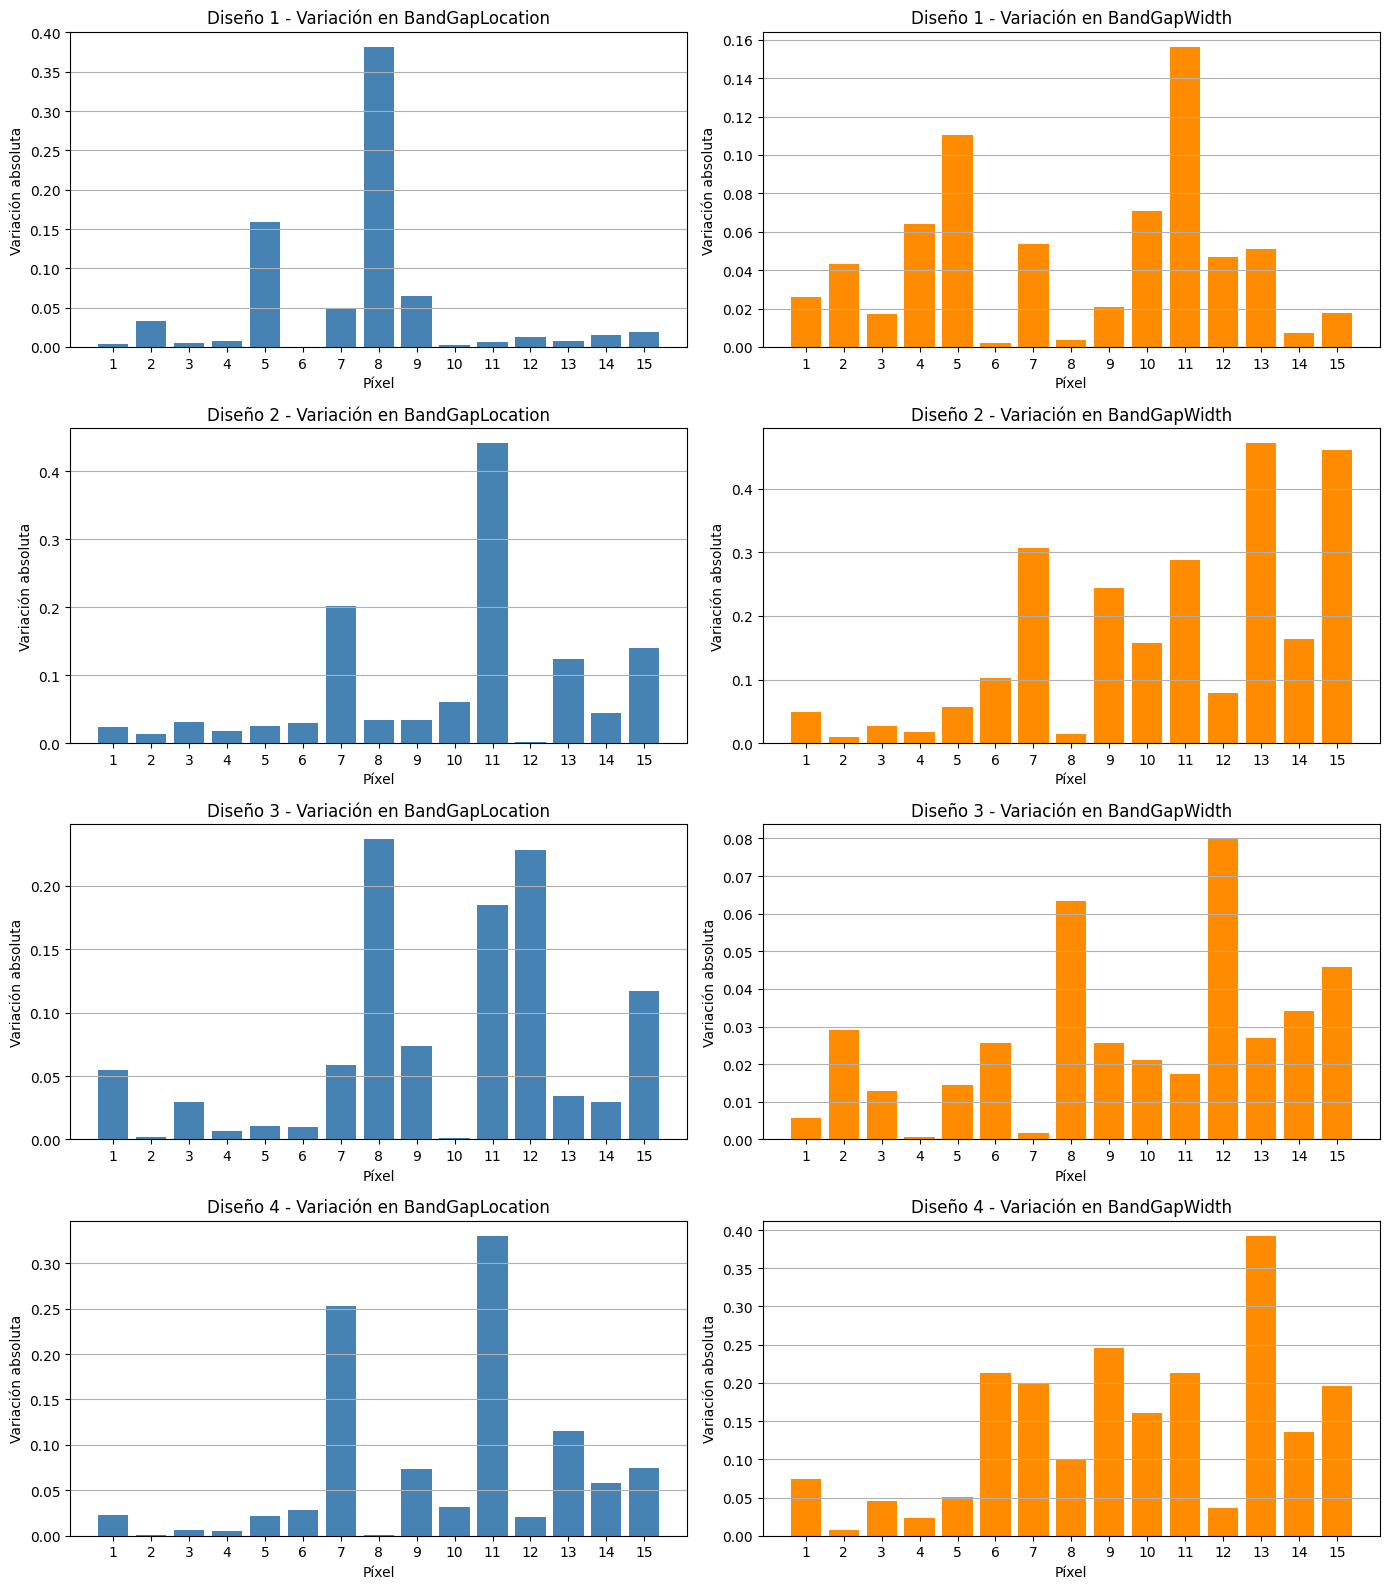


=== RESUMEN ===
Píxeles más influyentes en BandGapLocation por diseño : [8, 11, 8, 11]
Píxeles más influyentes en BandGapWidth por diseño    : [11, 13, 12, 13]
→ No siempre es el mismo píxel para BandGapLocation
→ No siempre es el mismo píxel para BandGapWidth


In [ ]:
# ============================================================
# PUNTO 3: Análisis de sensibilidad - Multiple Output
# ============================================================

np.random.seed(42)
indices_random = np.random.choice(len(x_test), size=4, replace=False)
disenios = x_test[indices_random]

print("4 diseños elegidos al azar:")
for i, d in enumerate(disenios):
    print(f"  Diseño {i+1}: {d}")

resultados_sensibilidad = []
for i, disenio in enumerate(disenios):
    prediccion_original = mejor_modelo.predict(disenio.reshape(1, -1), verbose=0)[0]
    loc_original = prediccion_original[0]
    width_original = prediccion_original[1]

    variaciones_loc = []
    variaciones_width = []

    for pixel in range(15):
        disenio_modificado = disenio.copy()
        disenio_modificado[pixel] = 1 - disenio_modificado[pixel]
        prediccion_modificada = mejor_modelo.predict(disenio_modificado.reshape(1, -1), verbose=0)[0]
        variaciones_loc.append(abs(prediccion_modificada[0] - loc_original))
        variaciones_width.append(abs(prediccion_modificada[1] - width_original))

    resultados_sensibilidad.append({
        'variaciones_loc': variaciones_loc,
        'variaciones_width': variaciones_width,
        'pixel_max_loc': np.argmax(variaciones_loc) + 1,
        'pixel_max_width': np.argmax(variaciones_width) + 1
    })

    print(f"\nDiseño {i+1}:")
    print(f"  Píxel con mayor variación en BandGapLocation : Píxel {np.argmax(variaciones_loc)+1} (variación={max(variaciones_loc):.4f})")
    print(f"  Píxel con mayor variación en BandGapWidth    : Píxel {np.argmax(variaciones_width)+1} (variación={max(variaciones_width):.4f})")

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
pixeles = np.arange(1, 16)

for i, res in enumerate(resultados_sensibilidad):
    axes[i, 0].bar(pixeles, res['variaciones_loc'], color='steelblue')
    axes[i, 0].set_title(f"Diseño {i+1} - Variación en BandGapLocation")
    axes[i, 0].set_xlabel("Píxel")
    axes[i, 0].set_ylabel("Variación absoluta")
    axes[i, 0].set_xticks(pixeles)
    axes[i, 0].grid(axis='y')

    axes[i, 1].bar(pixeles, res['variaciones_width'], color='darkorange')
    axes[i, 1].set_title(f"Diseño {i+1} - Variación en BandGapWidth")
    axes[i, 1].set_xlabel("Píxel")
    axes[i, 1].set_ylabel("Variación absoluta")
    axes[i, 1].set_xticks(pixeles)
    axes[i, 1].grid(axis='y')

plt.tight_layout()
plt.show()

print("\n=== RESUMEN ===")
pixels_loc   = [r['pixel_max_loc']   for r in resultados_sensibilidad]
pixels_width = [r['pixel_max_width'] for r in resultados_sensibilidad]

print(f"Píxeles más influyentes en BandGapLocation por diseño : {[int(p) for p in pixels_loc]}")
print(f"Píxeles más influyentes en BandGapWidth por diseño    : {[int(p) for p in pixels_width]}")
print("→ Siempre es el mismo píxel para BandGapLocation" if len(set(pixels_loc)) == 1 else "→ No siempre es el mismo píxel para BandGapLocation")
print("→ Siempre es el mismo píxel para BandGapWidth" if len(set(pixels_width)) == 1 else "→ No siempre es el mismo píxel para BandGapWidth")